# Przewidywanie cen mieszkań na podstawie cech nieruchomości
Opis: Model uczenia maszynowego przewidujący cenę mieszkania na podstawie liczby
pokoi, metrażu, lokalizacji itp.

Used dataset: **Ames Housing Dataset**

In [17]:
import kagglehub
import pandas as pd
import numpy as np
import os

if(not os.path.isdir('data')):
    path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir='./data')
    print("Path to dataset:", path)

df = pd.read_csv('./data/AmesHousing.csv')

print(df.shape)  # (2930, 82)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Przygotowanie danych

* Obsługa braków w danych
* Zamiana Stringów
* Usuwanie outliersów (Z-score, IQR method, visually)
* Standaryzacja (StandardScaler)
* Numeric skew transforms (log1p)

In [18]:
df.drop(columns=['Order', 'PID', 'Garage Yr Blt', 'Mo Sold', 'Condition 2', 'Roof Matl', 'Heating'], inplace=True)

In [19]:
# Fill categorical "absent" columns with 'None'
none_cols = [ 'Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond',
                'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                'Fireplace Qu', 'Garage Type', 'Garage Finish',
                'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature'
]
df[none_cols] = df[none_cols].fillna('None')

# Fill numeric absent columns with 0
zero_cols = [ 'Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                'Garage Cars', 'Garage Area'
]
df[zero_cols] = df[zero_cols].fillna(0)

df['Electrical'] = df['Electrical'].fillna('SBrkr')

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

ordinal_cols = {
    'Lot Shape':        ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Gtl', 'Mod', 'Sev'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Central Air':      ['N', 'Y'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Kitchen Qual':     ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Fireplace Qu':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y'],
    'Pool QC':          ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':            ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'Heating QC':       [ 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(
    categories=[order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
    )
    X_train[col] = enc.fit_transform(X_train[[col]]).ravel()
    X_test[col] = enc.transform(X_test[[col]]).ravel()

one_hot_cols = [ 'MS Zoning', 'Street', 'Alley', 'Land Contour',
                    'Lot Config', 'Bldg Type', 'House Style', 'Roof Style',
                    'Mas Vnr Type', 'Foundation',
                ]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=float)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_hot_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=one_hot_cols), ohe_test], axis=1)


target_cols = [ 'MS SubClass', 'Neighborhood', 'Condition 1', 'Garage Type',
                    'Misc Feature', 'Sale Type', 'Sale Condition', 'Exterior 1st',
                    'Exterior 2nd'
                ]

te = TargetEncoder(target_type="continuous", random_state=42)
X_train[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = te.transform(X_test[target_cols])

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

train_iso_mask  = iso.predict(X_train) == -1
train_iso_scores = iso.score_samples(X_train)

test_iso_mask   = iso.predict(X_test) == -1
test_iso_scores  = iso.score_samples(X_test)

print(f"Train outliers: {train_iso_mask.sum()} ({train_iso_mask.mean()*100:.1f}%)")
print(f"Test  outliers: {test_iso_mask.sum()}  ({test_iso_mask.mean()*100:.1f}%)")

Train outliers: 118 (5.0%)
Test  outliers: 33  (5.6%)


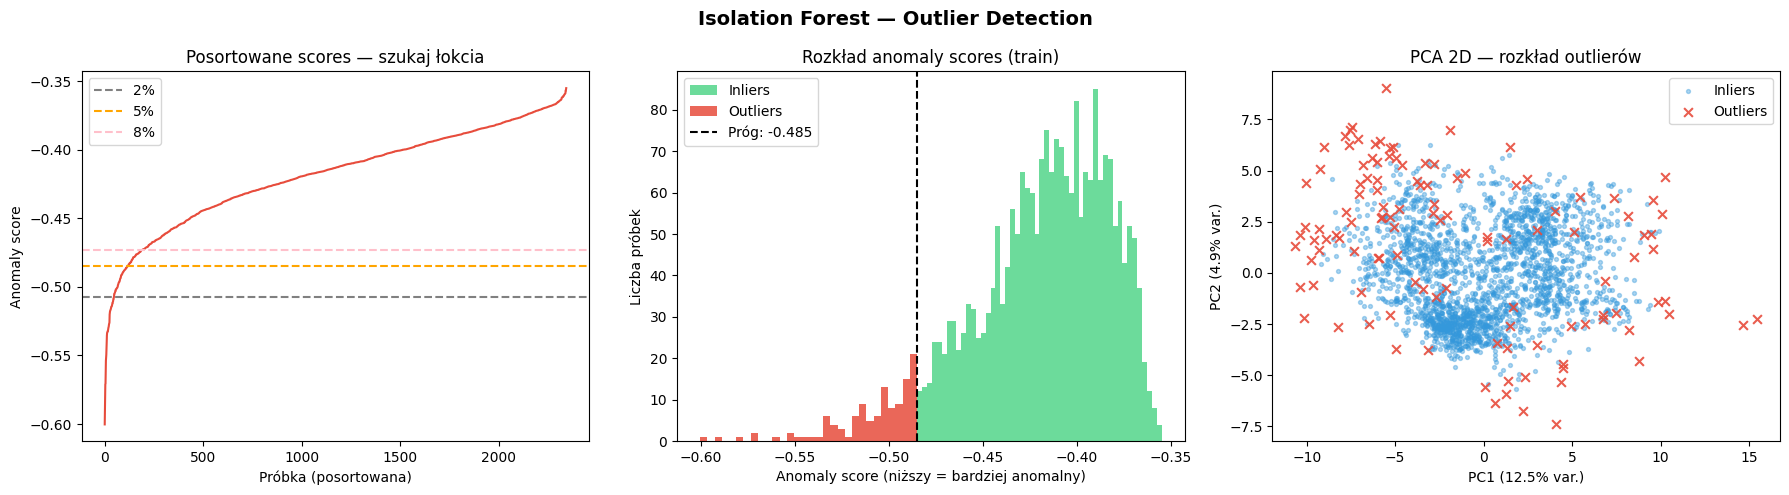

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Isolation Forest — Outlier Detection", fontsize=14, fontweight='bold')

# Elbow method for contamination
scores = iso.score_samples(X_train)
ax = axes[0]
ax.plot(np.sort(scores), color='#e74c3c', linewidth=1.5)
ax.set_title('Posortowane scores — szukaj łokcia')
ax.set_xlabel('Próbka (posortowana)')
ax.set_ylabel('Anomaly score')
ax.axhline(np.percentile(scores, 2), color='gray',
                linestyle='--', label='2%')
ax.axhline(np.percentile(scores, 5), color='orange',
                linestyle='--', label='5%')
ax.axhline(np.percentile(scores, 8), color='pink',
                linestyle='--', label='8%')
ax.legend()

# Histogram anomaly scores
ax = axes[1]
ax.hist(train_iso_scores[~train_iso_mask], bins=50,
        color='#2ecc71', alpha=0.7, label='Inliers')
ax.hist(train_iso_scores[train_iso_mask], bins=30,
        color='#e74c3c', alpha=0.85, label='Outliers')
ax.axvline(iso.offset_, color='black', linestyle='--',
           linewidth=1.5, label=f'Próg: {iso.offset_:.3f}')
ax.set_title('Rozkład anomaly scores (train)')
ax.set_xlabel('Anomaly score (niższy = bardziej anomalny)')
ax.set_ylabel('Liczba próbek')
ax.legend()

# PCA 2D scatter
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))

ax = axes[2]
ax.scatter(X_2d[~train_iso_mask, 0], X_2d[~train_iso_mask, 1],
           s=8, alpha=0.4, color='#3498db', label='Inliers')
ax.scatter(X_2d[train_iso_mask, 0], X_2d[train_iso_mask, 1],
           s=40, alpha=0.9, color='#e74c3c', marker='x',
           linewidths=1.5, label='Outliers')
ax.set_title('PCA 2D — rozkład outlierów')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend()

plt.tight_layout()
plt.show()

X_train_clean = X_train[~train_iso_mask]
y_train_clean = y_train[~train_iso_mask]
X_test_clean = X_test[~test_iso_mask]
y_test_clean = y_test[~test_iso_mask]

In [24]:
scaler = StandardScaler()
X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled  = scaler.transform(X_test_clean)

print(f"X_train_clean: {X_train_clean_scaled.shape}")
print(f"X_test_clean:  {X_test_clean_scaled.shape}")
print(f"y_train_clean: {y_train_clean.shape}")
print(f"y_test_clean:  {y_test_clean.shape}")

X_train_clean: (2226, 115)
X_test_clean:  (553, 115)
y_train_clean: (2226,)
y_test_clean:  (553,)


# Wizualizacja danych

* Rozkład ceny (y) — histogram + log-transform
* Top 20 cech wg korelacji z ceną
* Scatter plots tych cech vs cena
* Macierz korelacji (top 20)
* Wykresy 3D (6 sztuk)
* PCA / t-SNE / UMAP w 2D (kolorowane ceną)

## 1. Rozkład ceny (SalePrice)

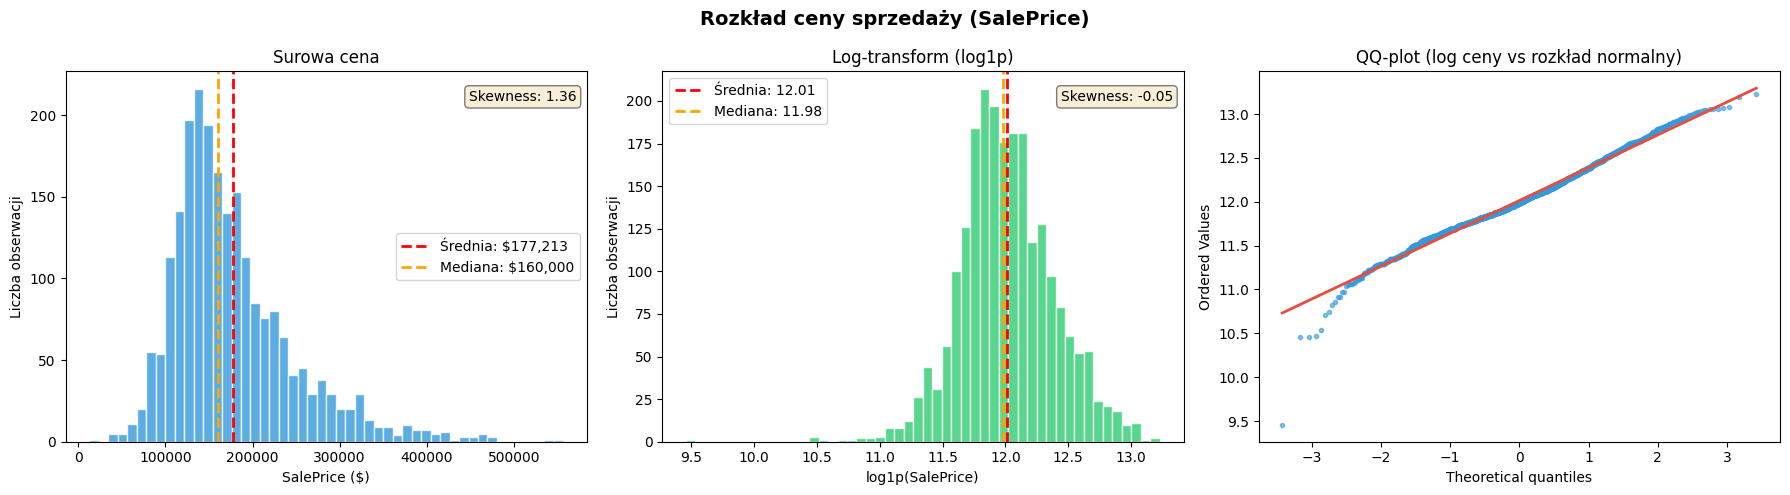

Skewness surowej ceny:       1.356  (|>1| = warto stosować log)
Skewness po log-transform:   -0.052  (im bliżej 0, tym lepiej)


In [25]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rozkład ceny sprzedaży (SalePrice)', fontsize=14, fontweight='bold')

y_all = y_train_clean  # używamy czystych danych treningowych

# Histogram surowej ceny
ax = axes[0]
ax.hist(y_all, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(y_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: ${y_all.mean():,.0f}')
ax.axvline(y_all.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: ${y_all.median():,.0f}')
ax.set_title('Surowa cena')
ax.set_xlabel('SalePrice ($)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_val = stats.skew(y_all)
ax.text(0.98, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Log-transform
y_log = np.log1p(y_all)
ax = axes[1]
ax.hist(y_log, bins=50, color='#2ecc71', alpha=0.8, edgecolor='white')
ax.axvline(y_log.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: {y_log.mean():.2f}')
ax.axvline(y_log.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {y_log.median():.2f}')
ax.set_title('Log-transform (log1p)')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_log = stats.skew(y_log)
ax.text(0.98, 0.95, f'Skewness: {skew_log:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# QQ-plot
ax = axes[2]
stats.probplot(y_log, dist='norm', plot=ax)
ax.set_title('QQ-plot (log ceny vs rozkład normalny)')
ax.get_lines()[0].set(color='#3498db', alpha=0.6, markersize=3)
ax.get_lines()[1].set(color='#e74c3c', linewidth=2)

plt.tight_layout()
plt.show()

print(f"Skewness surowej ceny:       {skew_val:.3f}  (|>1| = warto stosować log)")
print(f"Skewness po log-transform:   {skew_log:.3f}  (im bliżej 0, tym lepiej)")

## 2. Analiza statystyczna — Top 20 cech wg korelacji z ceną

=== Statystyki Top 20 cech ===
                        mean        std        min         25%         50%         75%         max  corr_with_price
Overall Qual           6.074      1.326      1.000       5.000       6.000       7.000      10.000            0.803
Neighborhood      178565.738  55943.716  95608.332  135206.256  160078.937  201008.571  336712.207            0.746
Gr Liv Area         1469.233    461.979    407.000    1118.250    1429.500    1717.000    3672.000            0.720
Exter Qual             2.391      0.557      1.000       2.000       2.000       3.000       4.000            0.689
Kitchen Qual           2.496      0.634      1.000       2.000       2.000       3.000       4.000            0.657
Garage Cars            1.762      0.708      0.000       1.000       2.000       2.000       4.000            0.656
Garage Area          471.889    199.916      0.000     326.500     477.500     576.000    1488.000            0.641
Total Bsmt SF       1042.619    398.866  

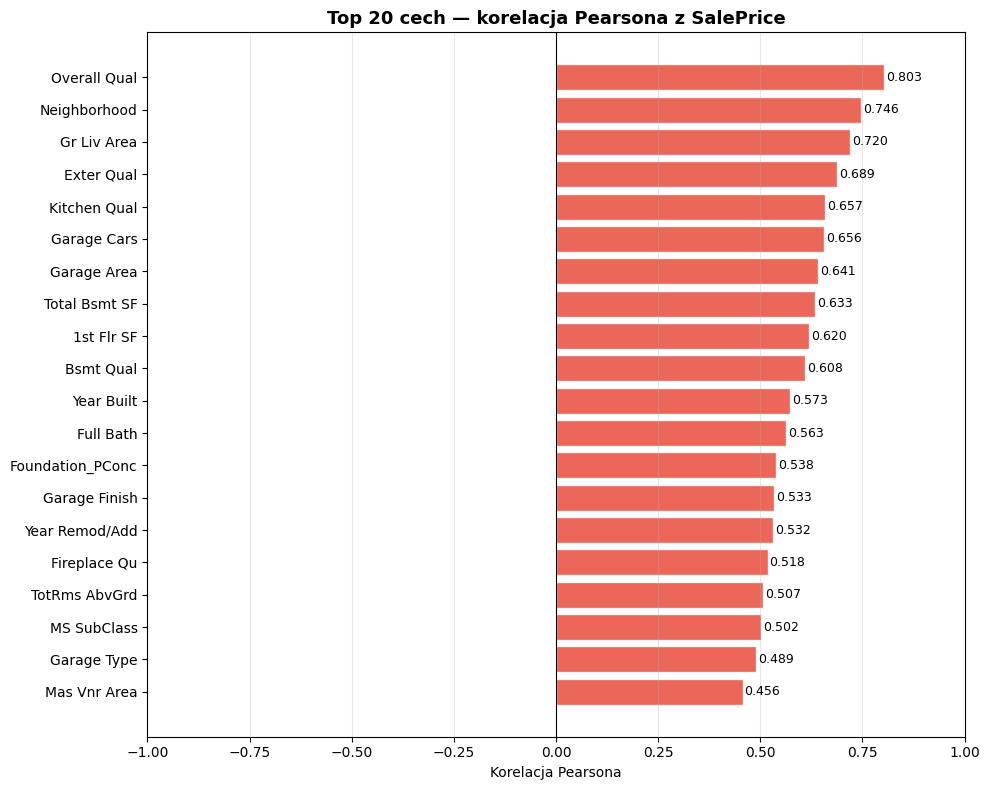

In [26]:
# Budujemy DataFrame z oryginalnych (niestandardyzowanych) kolumn + cena
# X_train_clean to pandas DataFrame przed skalowaniem
df_analysis = X_train_clean.copy()
df_analysis['SalePrice'] = y_train_clean.values

# Korelacja Pearsona z ceną
corr_with_price = df_analysis.corr()['SalePrice'].drop('SalePrice')
top20 = corr_with_price.abs().nlargest(20).index.tolist()
top20_corr = corr_with_price[top20].sort_values(ascending=True)

# Tabela statystyk
stats_table = df_analysis[top20].describe().T
stats_table['corr_with_price'] = corr_with_price[top20]
print("=== Statystyki Top 20 cech ===")
print(stats_table[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'corr_with_price']].round(3).to_string())

# Wykres poziomy — korelacja
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top20_corr]
bars = ax.barh(top20_corr.index, top20_corr.values, color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, top20_corr.values):
    ax.text(val + (0.005 if val > 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 cech — korelacja Pearsona z SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Korelacja Pearsona')
ax.set_xlim(-1, 1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Scatter plots — Top 20 cech vs SalePrice

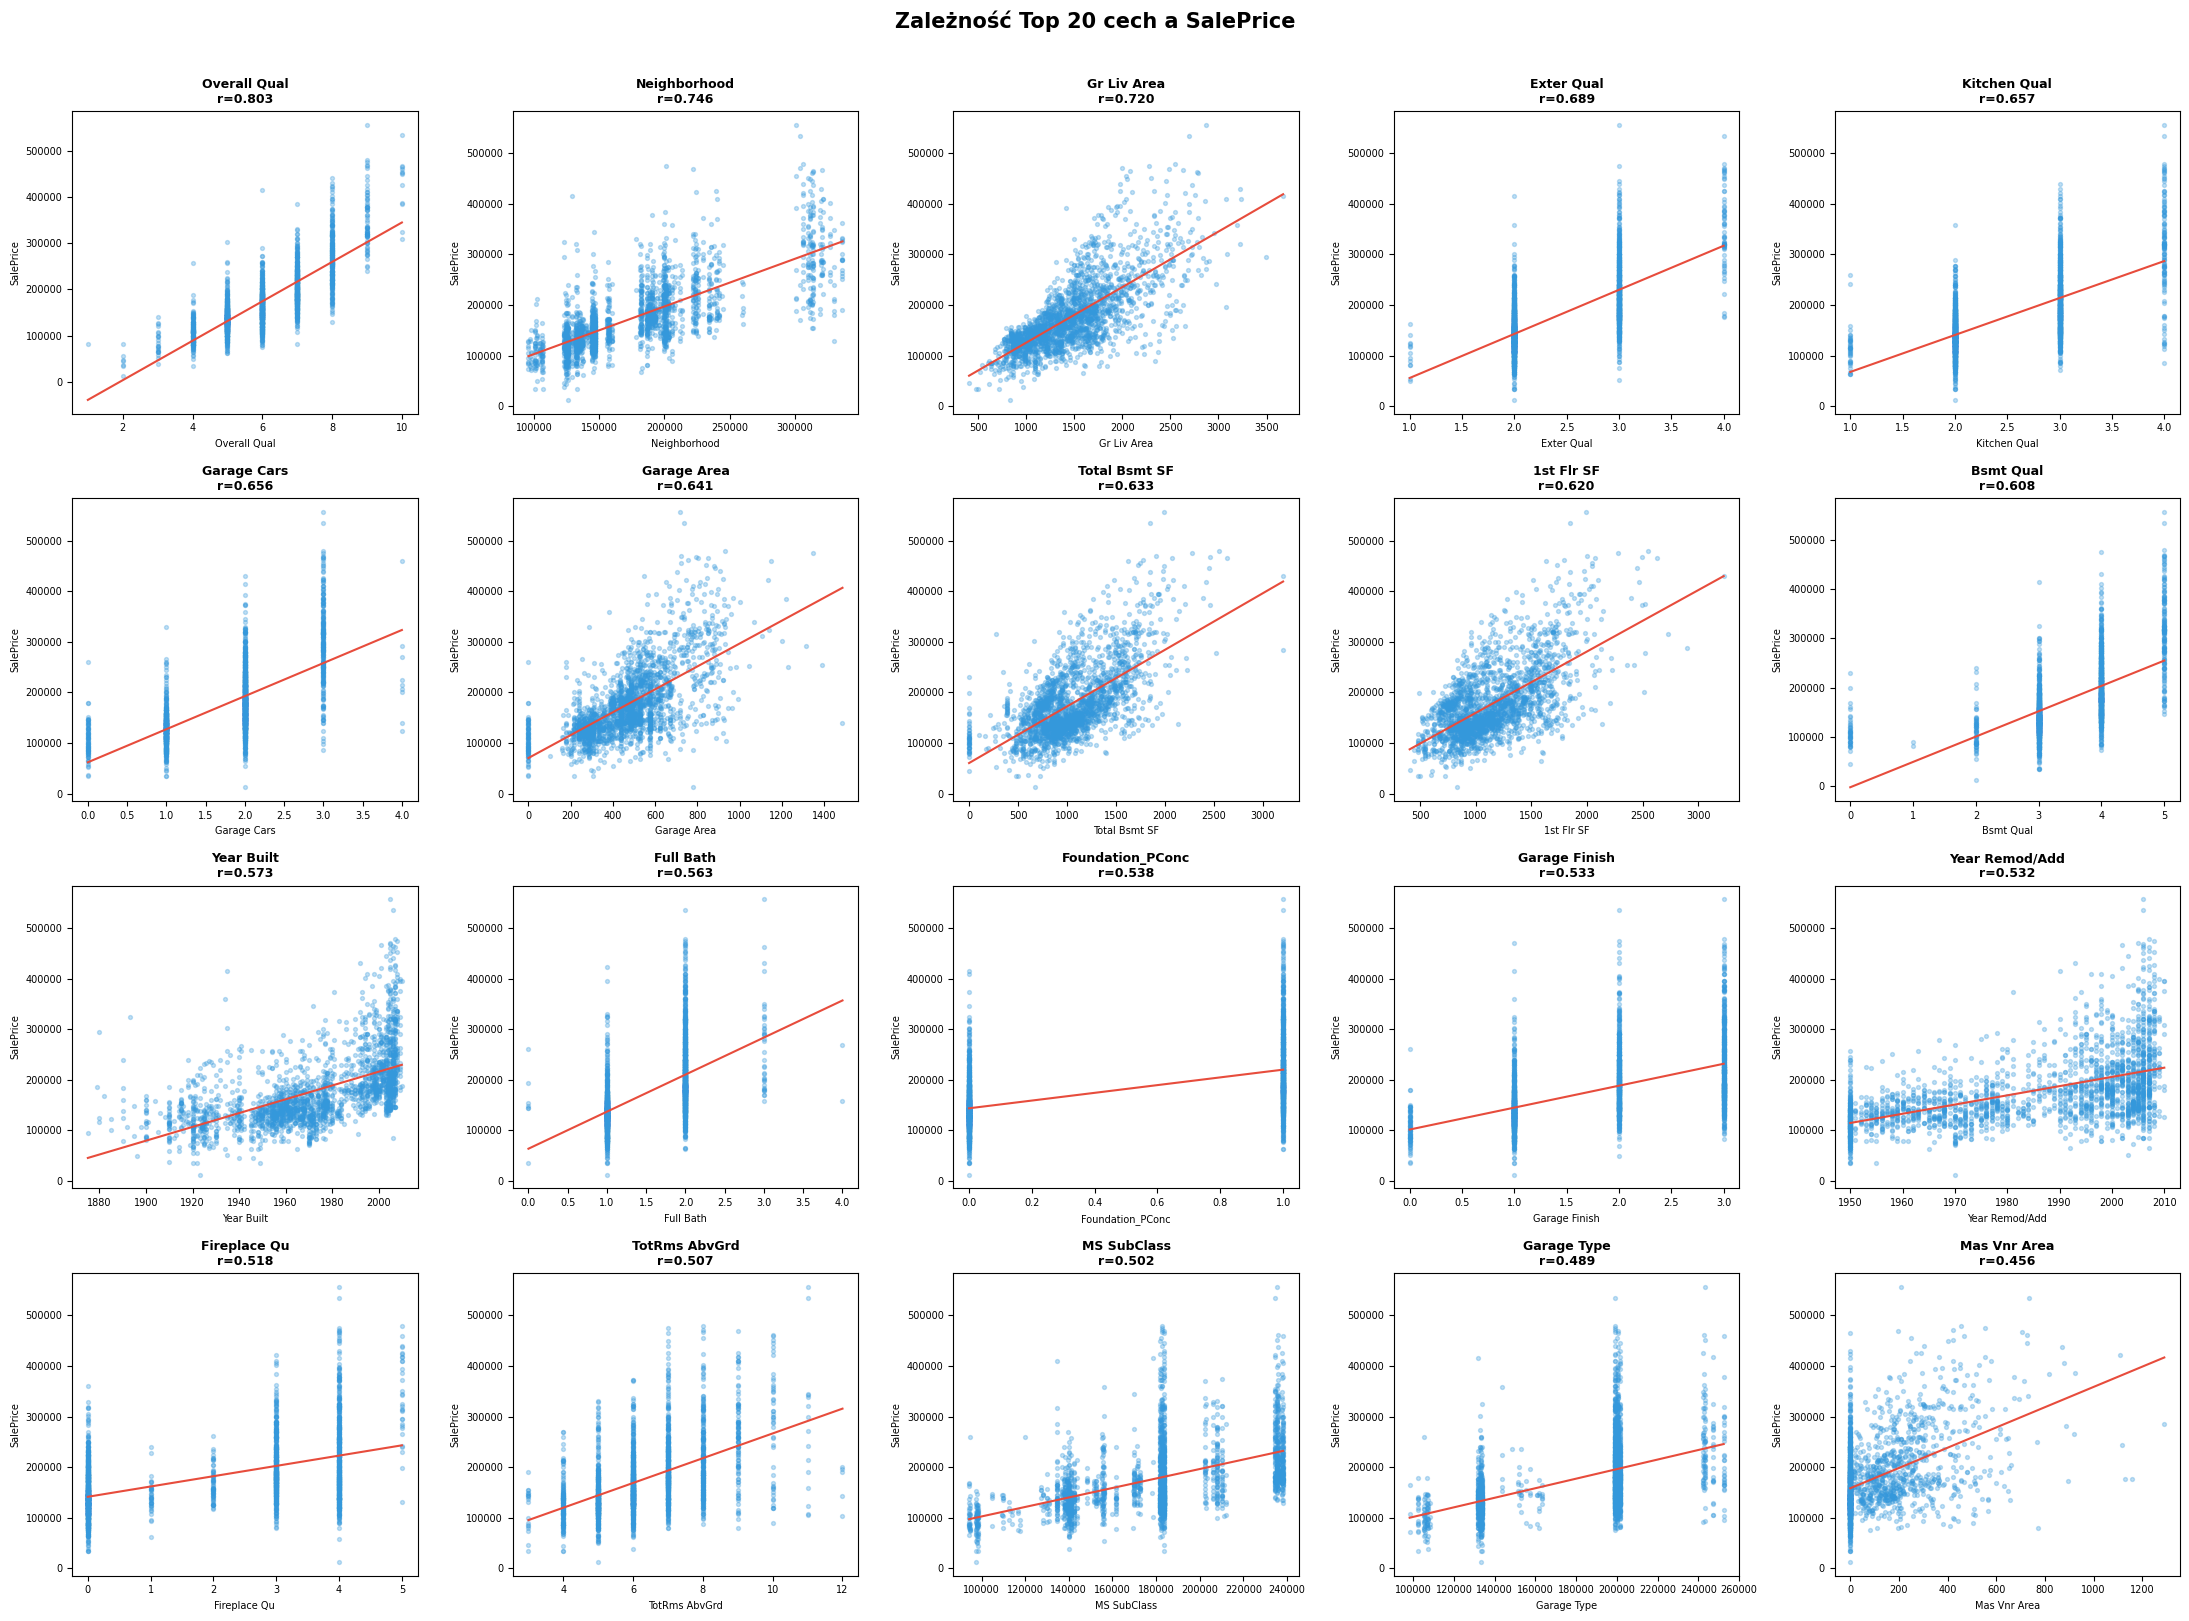

In [27]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
fig.suptitle('Zależność Top 20 cech a SalePrice', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

top20_sorted = corr_with_price.abs().nlargest(20).index.tolist()

for i, col in enumerate(top20_sorted):
    ax = axes[i]
    r = corr_with_price[col]
    ax.scatter(df_analysis[col], df_analysis['SalePrice'],
               alpha=0.3, s=8, color='#3498db')
    
    # Linia trendu
    m, b = np.polyfit(df_analysis[col].dropna(), 
                      df_analysis.loc[df_analysis[col].notna(), 'SalePrice'], 1)
    x_line = np.linspace(df_analysis[col].min(), df_analysis[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=1.5)
    
    ax.set_title(f'{col}\nr={r:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(col, fontsize=7)
    ax.set_ylabel('SalePrice', fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 4. Macierz korelacji (Top 20 cech)

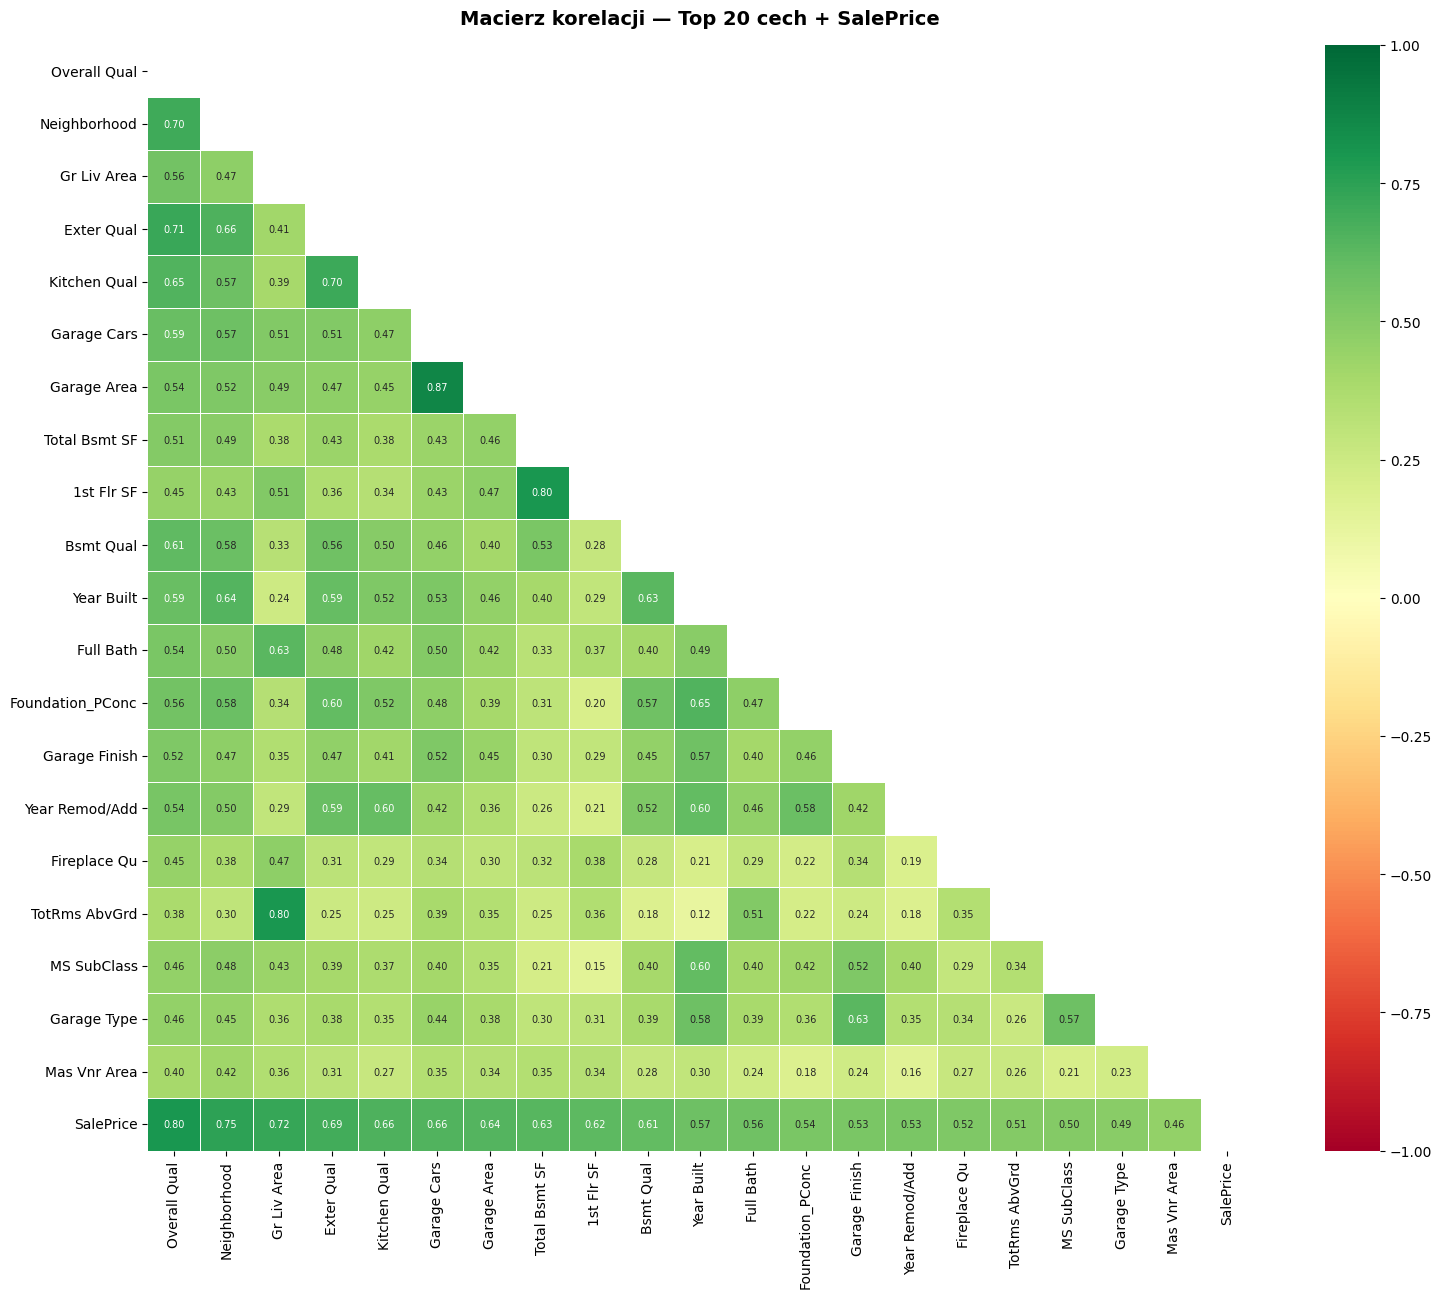


=== Pary cech z korelacją > 0.7 (ryzyko multikolinearności) ===
  Garage Cars                    <-> Garage Area                     r=0.875
  Overall Qual                   <-> SalePrice                       r=0.803
  Gr Liv Area                    <-> TotRms AbvGrd                   r=0.803
  Total Bsmt SF                  <-> 1st Flr SF                      r=0.803
  Neighborhood                   <-> SalePrice                       r=0.746
  Gr Liv Area                    <-> SalePrice                       r=0.72
  Overall Qual                   <-> Exter Qual                      r=0.712
  Exter Qual                     <-> Kitchen Qual                    r=0.704


In [28]:
import seaborn as sns

cols_for_corr = top20_sorted + ['SalePrice']
corr_matrix = df_analysis[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # tylko dolny trójkąt

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Macierz korelacji — Top 20 cech + SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Pary cech z korelacją > 0.7 (multikolinearność)
print("\n=== Pary cech z korelacją > 0.7 (ryzyko multikolinearności) ===")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(c, 3)))
for a, b, c in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {a:30s} <-> {b:30s}  r={c}")

## 5. Wykresy 3D — dwie cechy × cena

C:\Users\Staszek\AppData\Local\Temp\ipykernel_21660\434734820.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


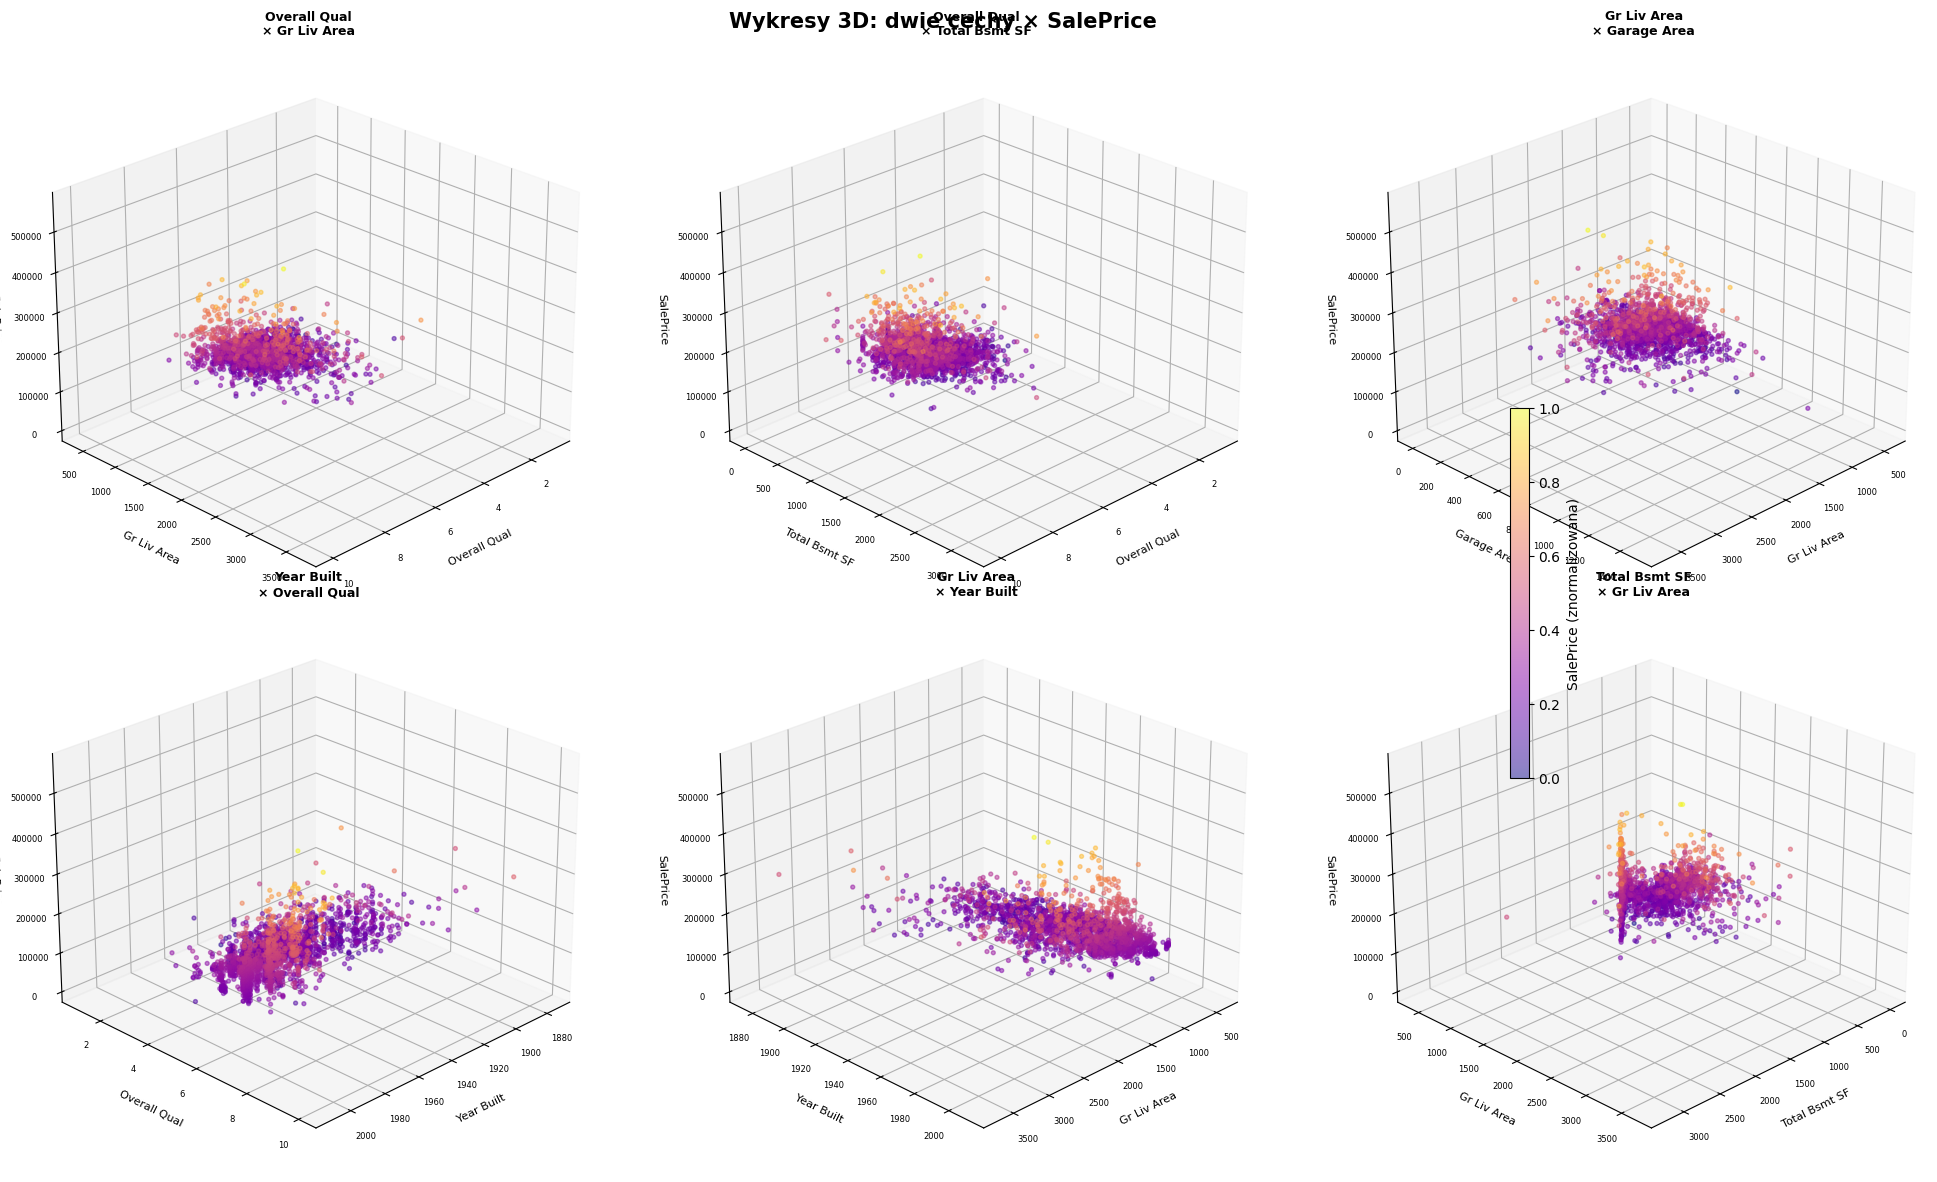

In [29]:
from mpl_toolkits.mplot3d import Axes3D

# 6 par cech (wybrane spośród top korelacji)
feature_pairs = [
    ('Overall Qual', 'Gr Liv Area'),
    ('Overall Qual', 'Total Bsmt SF'),
    ('Gr Liv Area',  'Garage Area'),
    ('Year Built',   'Overall Qual'),
    ('Gr Liv Area',  'Year Built'),
    ('Total Bsmt SF','Gr Liv Area'),
]

# Sprawdzamy które cechy istnieją w df_analysis
available = df_analysis.columns.tolist()
feature_pairs = [(a, b) for a, b in feature_pairs if a in available and b in available]

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Wykresy 3D: dwie cechy × SalePrice', fontsize=15, fontweight='bold')

price = df_analysis['SalePrice'].values
price_norm = (price - price.min()) / (price.max() - price.min())  # normalizacja do koloru

for idx, (feat_x, feat_y) in enumerate(feature_pairs[:6]):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    x = df_analysis[feat_x].values
    y = df_analysis[feat_y].values
    z = price
    
    sc = ax.scatter(x, y, z, c=price_norm, cmap='plasma', s=8, alpha=0.5)
    ax.set_xlabel(feat_x, fontsize=8, labelpad=5)
    ax.set_ylabel(feat_y, fontsize=8, labelpad=5)
    ax.set_zlabel('SalePrice', fontsize=8, labelpad=5)
    ax.set_title(f'{feat_x}\n× {feat_y}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=45)

plt.colorbar(sc, ax=fig.axes, label='SalePrice (znormalizowana)', shrink=0.4, pad=0.05)
plt.tight_layout()
plt.show()

## 6. Redukcja wymiarów do 2D: PCA / t-SNE / UMAP (kolorowane ceną)

Liczenie PCA...
PCA wyjaśniona wariancja: PC1=14.2%, PC2=5.2%
Liczenie t-SNE...
Liczenie UMAP...
  UMAP nie zainstalowany — pip install umap-learn
Rysowanie...


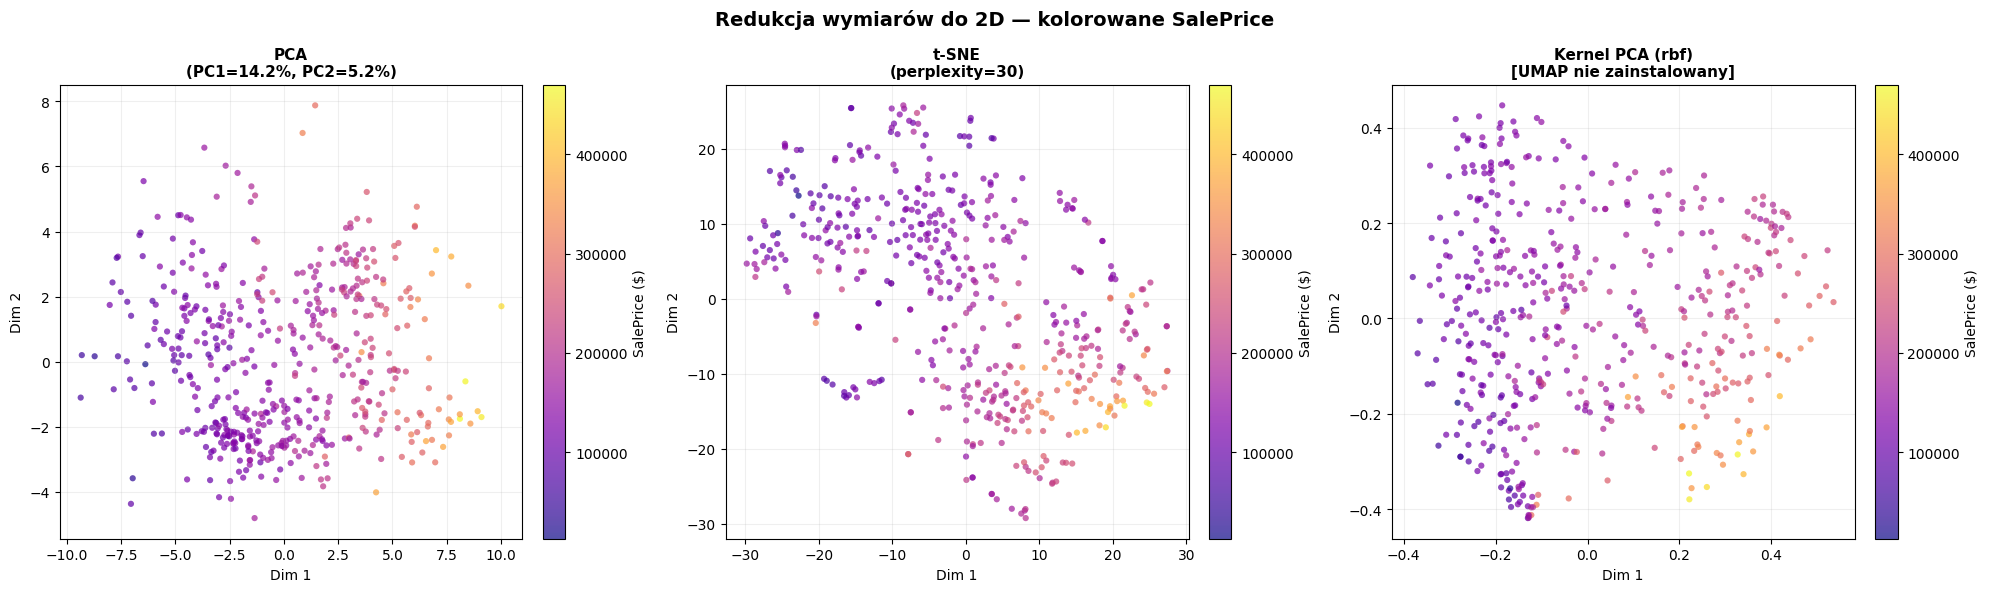

In [30]:
from sklearn.manifold import TSNE

# Próbka 500 punktów (t-SNE i UMAP są wolne na pełnych danych)
np.random.seed(42)
n_sample = min(500, X_train_clean_scaled.shape[0])
idx_sample = np.random.choice(X_train_clean_scaled.shape[0], n_sample, replace=False)
X_sample = X_train_clean_scaled[idx_sample]
y_sample = y_train_clean.values[idx_sample]

print("Liczenie PCA...")
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_sample)
print(f"PCA wyjaśniona wariancja: PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca2.explained_variance_ratio_[1]*100:.1f}%")

print("Liczenie t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_sample)

print("Liczenie UMAP...")
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, verbose=False)
    X_umap = reducer.fit_transform(X_sample)
    umap_available = True
except ImportError:
    print("  UMAP nie zainstalowany — pip install umap-learn")
    # Fallback: Kernel PCA
    from sklearn.decomposition import KernelPCA
    kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42)
    X_umap = kpca.fit_transform(X_sample)
    umap_available = False

print("Rysowanie...")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Redukcja wymiarów do 2D — kolorowane SalePrice', fontsize=14, fontweight='bold')

datasets = [
    (X_pca,  f'PCA\n(PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca2.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_tsne, 't-SNE\n(perplexity=30)'),
    (X_umap, 'UMAP' if umap_available else 'Kernel PCA (rbf)\n[UMAP nie zainstalowany]'),
]

for ax, (X_2d, title) in zip(axes, datasets):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample,
                    cmap='plasma', s=20, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='SalePrice ($)', fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7. PCA — Scree plot i loadings (które cechy tworzą PC1)

Liczba PC do 90% wariancji: 64
Liczba PC do 95% wariancji: 76


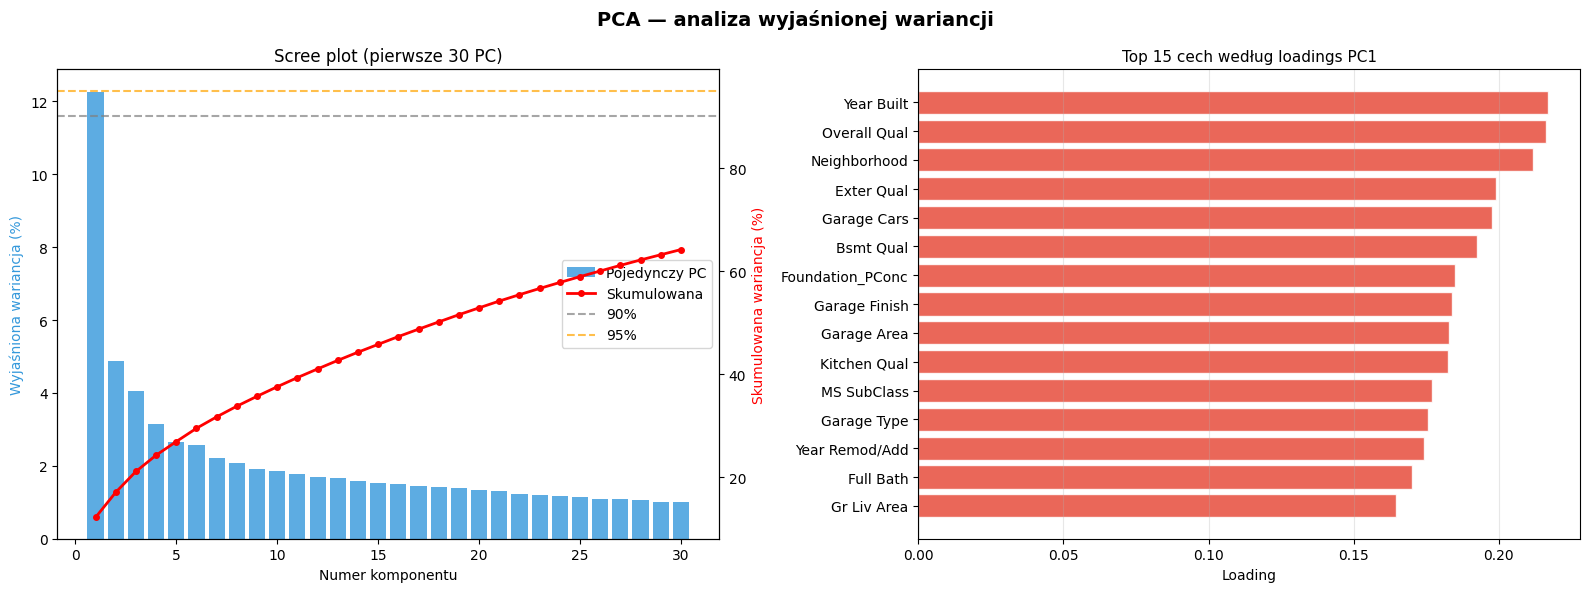

In [31]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_clean_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.searchsorted(cumvar, 0.90) + 1
n_95 = np.searchsorted(cumvar, 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA — analiza wyjaśnionej wariancji', fontsize=14, fontweight='bold')

# Scree plot
ax = axes[0]
ax.bar(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100,
       color='#3498db', alpha=0.8, label='Pojedynczy PC')
ax2 = ax.twinx()
ax2.plot(range(1, 31), cumvar[:30] * 100, 'r-o', markersize=4, linewidth=2, label='Skumulowana')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.7, label='90%')
ax2.axhline(95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax.set_xlabel('Numer komponentu')
ax.set_ylabel('Wyjaśniona wariancja (%)', color='#3498db')
ax2.set_ylabel('Skumulowana wariancja (%)', color='red')
ax.set_title('Scree plot (pierwsze 30 PC)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
print(f"Liczba PC do 90% wariancji: {n_90}")
print(f"Liczba PC do 95% wariancji: {n_95}")

# Top loadings PC1
ax = axes[1]
feature_names = X_train_clean.columns.tolist()
pc1_loadings = pd.Series(pca_full.components_[0], index=feature_names)
top_pc1 = pc1_loadings.abs().nlargest(15)
vals = pc1_loadings[top_pc1.index].sort_values(ascending=True)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in vals]
ax.barh(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 cech według loadings PC1', fontsize=11)
ax.set_xlabel('Loading')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Modele

* Regresja liniowa (Linear Regression)
* Drzewo decyzyjne (Decision Tree Regressor)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    """Trenuje i ocenia model, zwraca słownik metryk."""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    metrics = {
        'Model': name,
        'R² train':   round(r2_score(y_train, y_pred_train), 4),
        'R² test':    round(r2_score(y_test,  y_pred_test),  4),
        'RMSE train': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'RMSE test':  round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),  2),
        'MAE test':   round(mean_absolute_error(y_test, y_pred_test), 2),
    }
    return metrics, y_pred_test

lr  = LinearRegression()
dt  = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)

results = []
preds   = {}

for model, name in [(lr, 'Linear Regression'), (dt, 'Decision Tree')]:
    m, p = evaluate_model(model, X_train_clean_scaled, y_train_clean,
                                  X_test_clean_scaled,  y_test_clean, name)
    results.append(m)
    preds[name] = p

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                   R² train  R² test  RMSE train  RMSE test  MAE test
Model                                                                
Linear Regression    0.9165   0.9194    20352.20   24261.05  16842.16
Decision Tree        0.9140   0.8617    20653.22   31775.74  21086.97


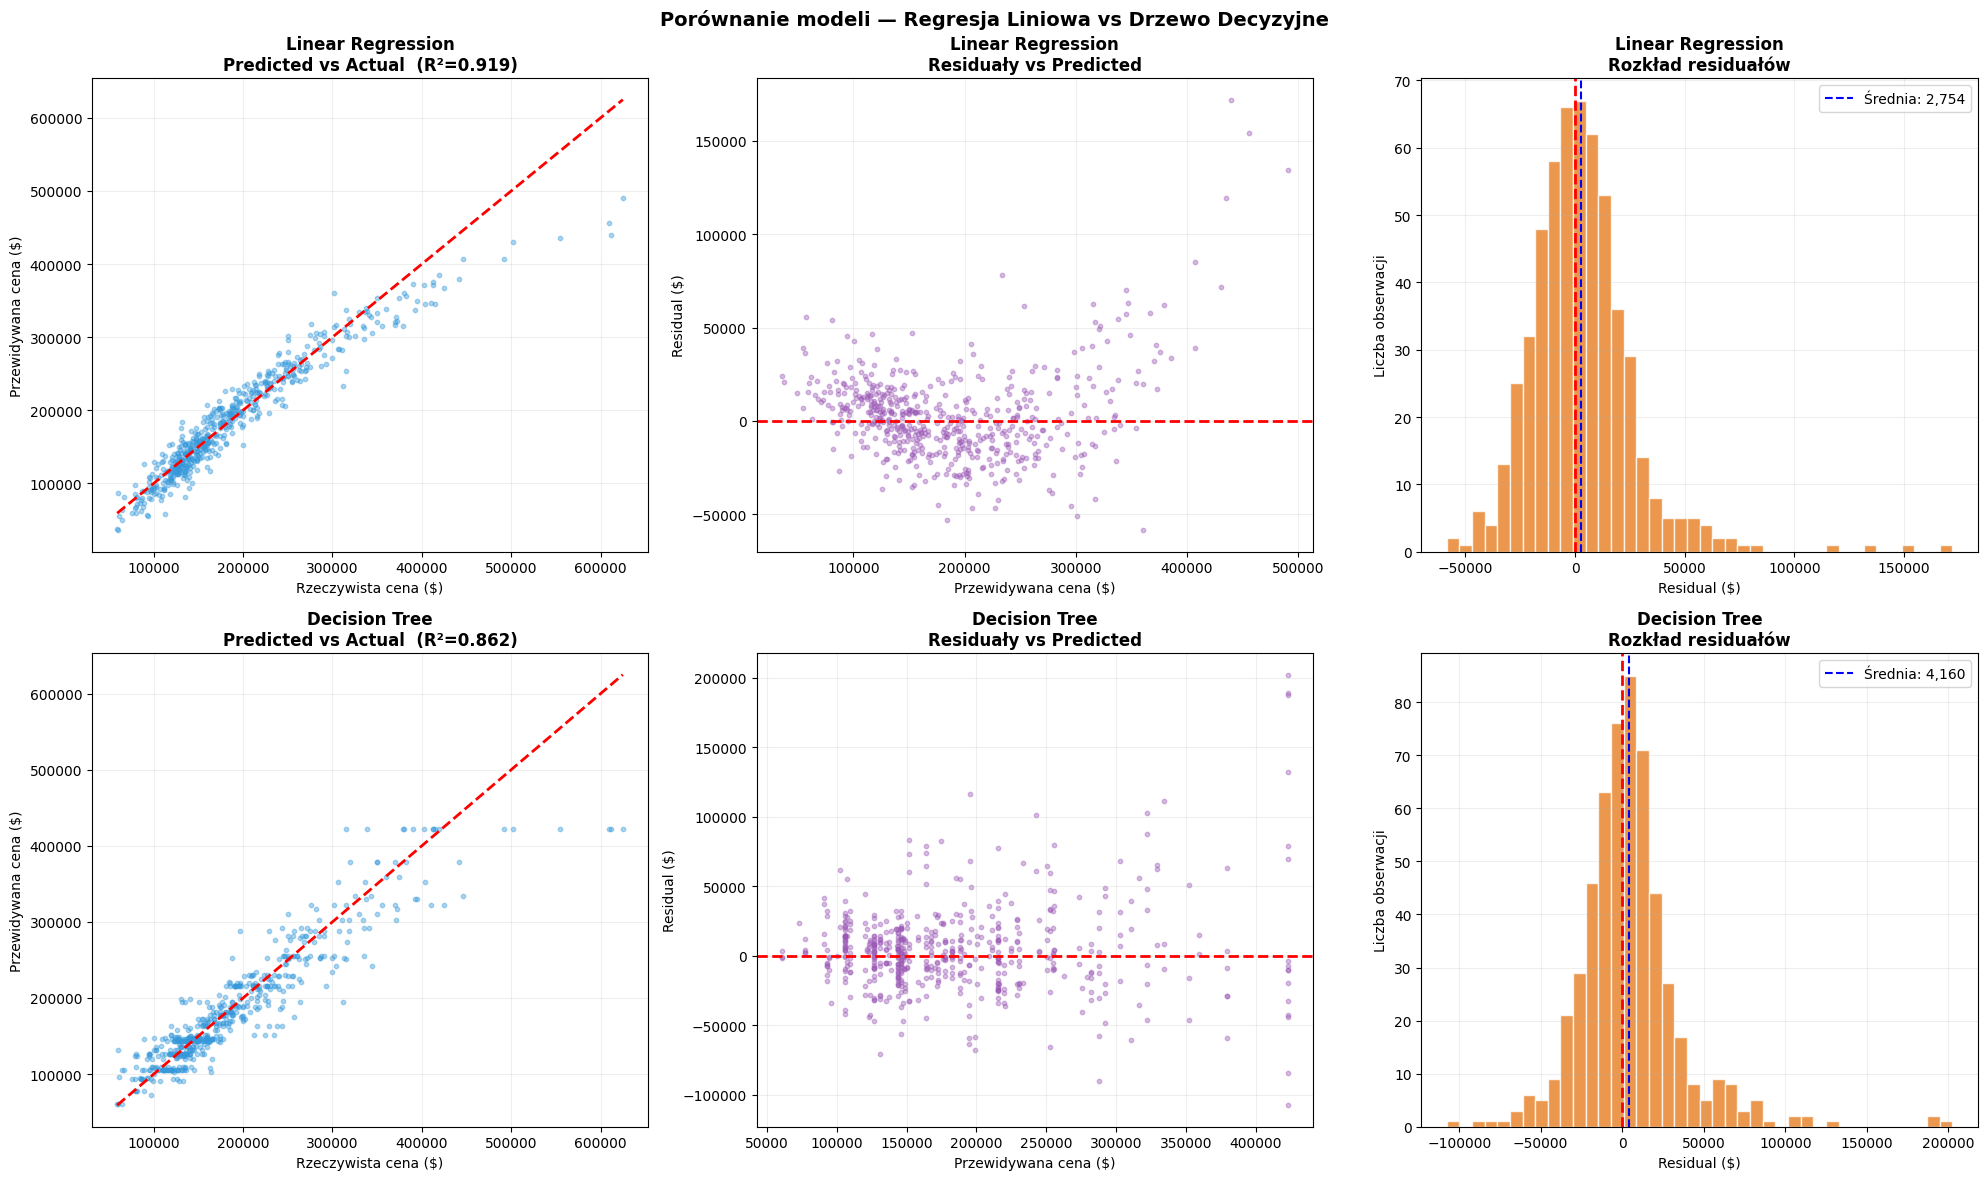

In [33]:
# Wykresy porównawcze modeli
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Porównanie modeli — Regresja Liniowa vs Drzewo Decyzyjne', fontsize=14, fontweight='bold')

y_true = y_test_clean.values

for row, (name, y_pred) in enumerate(preds.items()):
    residuals = y_true - y_pred

    # Predicted vs Actual
    ax = axes[row, 0]
    ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='#3498db')
    mn, mx = y_true.min(), y_true.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_xlabel('Rzeczywista cena ($)')
    ax.set_ylabel('Przewidywana cena ($)')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f'{name}\nPredicted vs Actual  (R²={r2:.3f})', fontweight='bold')
    ax.grid(alpha=0.2)

    # Residuals vs Predicted
    ax = axes[row, 1]
    ax.scatter(y_pred, residuals, alpha=0.4, s=10, color='#9b59b6')
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Przewidywana cena ($)')
    ax.set_ylabel('Residual ($)')
    ax.set_title(f'{name}\nResiduały vs Predicted', fontweight='bold')
    ax.grid(alpha=0.2)

    # Histogram residuałów
    ax = axes[row, 2]
    ax.hist(residuals, bins=40, color='#e67e22', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.axvline(residuals.mean(), color='blue', linestyle='--', linewidth=1.5,
               label=f'Średnia: {residuals.mean():,.0f}')
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Liczba obserwacji')
    ax.set_title(f'{name}\nRozkład residuałów', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

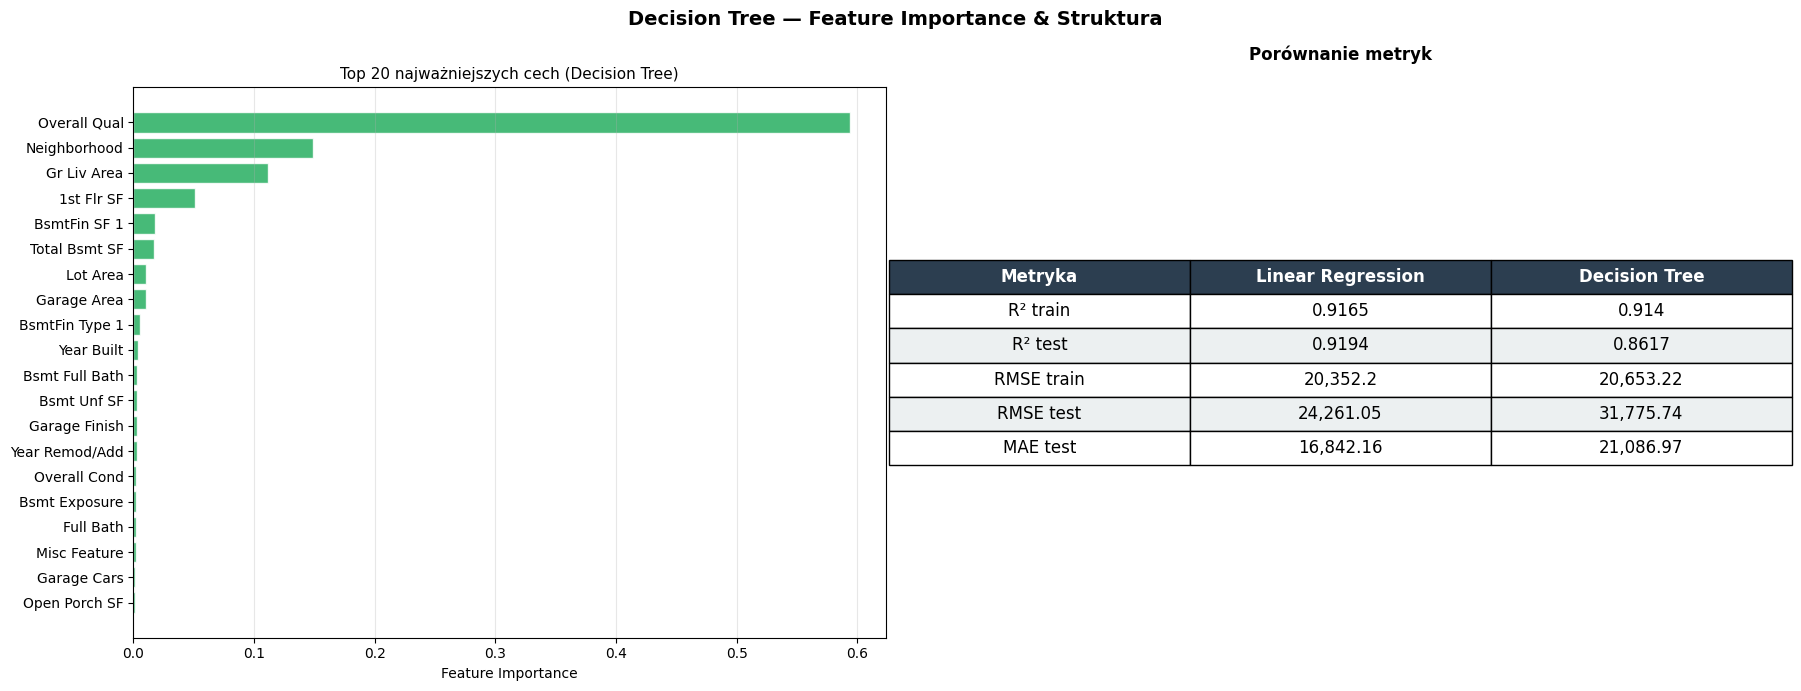

In [34]:
# Feature importance — Decision Tree
feature_imp = pd.Series(dt.feature_importances_, index=X_train_clean.columns)
top_imp = feature_imp.nlargest(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Decision Tree — Feature Importance & Struktura', fontsize=14, fontweight='bold')

ax = axes[0]
ax.barh(top_imp.index, top_imp.values, color='#27ae60', alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 najważniejszych cech (Decision Tree)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Metryki zbiorczo
ax = axes[1]
ax.axis('off')
table_data = [['Metryka', 'Linear Regression', 'Decision Tree']]
for metric in ['R² train', 'R² test', 'RMSE train', 'RMSE test', 'MAE test']:
    row = [metric]
    for model_name in ['Linear Regression', 'Decision Tree']:
        row.append(f"{results_df.loc[model_name, metric]:,}")
    table_data.append(row)

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
ax.set_title('Porównanie metryk', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()